In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
df.drop("User ID",axis=1,inplace=True)

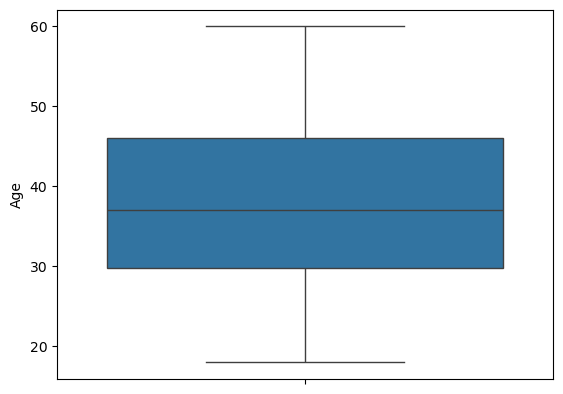

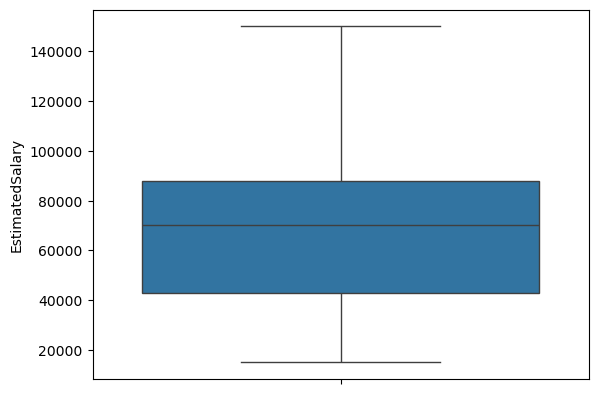

In [6]:
num_cols=["Age","EstimatedSalary"]
for i in num_cols:
    sns.boxplot(df[i])
    plt.show()
# no outliers

In [8]:
from scipy.stats import skew
for i in num_cols:
    print(f"{i} : {skew(df[i])}")

Age : 0.23046904236325927
EstimatedSalary : 0.49316535320478544


In [9]:
# object encoding
obj_cols=["Gender","Purchased"]
for i in obj_cols:
    print(f"{i} :{df[i].nunique()} \n {df[i].value_counts()}")

Gender :2 
 Gender
Female    204
Male      196
Name: count, dtype: int64
Purchased :2 
 Purchased
0    257
1    143
Name: count, dtype: int64


In [15]:
'''
df["Gender"].replace({
    "Female":0,
    "Male":1
})

df["Gender"].map({"Female":0,
    "Male":1})
    
df["Gender"].apply(lambda x:1 if x=="Male"  else 0)
'''
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])

In [23]:
features=df.drop("Purchased",axis=1)
target=df["Purchased"]

In [24]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
features.iloc[:]=ss.fit_transform(features.iloc[:])
features

,Gender,Age,EstimatedSalary
0,1.020204,-1.781797,-1.490046
1,1.020204,-0.253587,-1.460681
2,-0.980196,-1.113206,-0.785290
3,-0.980196,-1.017692,-0.374182
4,1.020204,-1.781797,0.183751
...,...,...,...
395,-0.980196,0.797057,-0.844019
396,1.020204,1.274623,-1.372587
397,-0.980196,1.179110,-1.460681
398,1.020204,-0.158074,-1.078938


In [25]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,random_state=0,test_size=0.2,
                                           stratify=target)
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(320, 3) (320,)
(80, 3) (80,)


In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [27]:
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    #Overfitting - underfitting check
    print(f"Training score : {model.score(xtrain,ytrain)}")
    print(f"Testing score : {model.score(xtest,ytest)}")
    c=pd.DataFrame(confusion_matrix(ypred,ytest),
                  index=["Not Purchased","Purchased"],
                  columns=["Not Purchased","Purchased"])
    print("Confusion Matrix : \n",c)
    print("Classification Report : \n",classification_report(ytest,ypred))
    return model

In [28]:
mymodel(KNeighborsClassifier())

Training score : 0.925
Testing score : 0.9125
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             48          4
Purchased                  3         25
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        51
           1       0.89      0.86      0.88        29

    accuracy                           0.91        80
   macro avg       0.91      0.90      0.90        80
weighted avg       0.91      0.91      0.91        80



KNeighborsClassifier()

In [29]:
# hyperparameter tuning
tr_ac=[]
te_ac=[]
for i in range(3,51,2):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(xtrain,ytrain)
    tr_ac.append(model.score(xtrain,ytrain))
    te_ac.append(model.score(xtest,ytest))

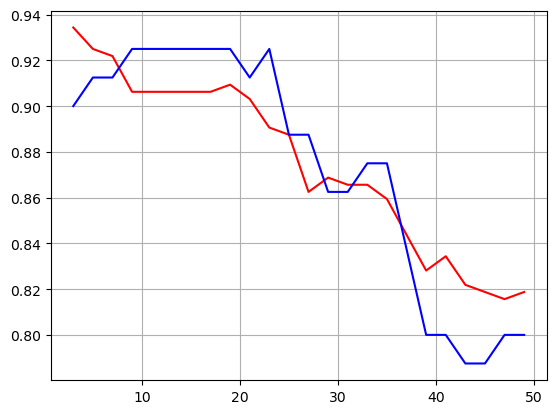

In [31]:
plt.plot(range(3,51,2),tr_ac,color="red")
plt.plot(range(3,51,2),te_ac,color="blue")
plt.grid(True)
plt.show()

In [33]:
knn=mymodel(KNeighborsClassifier(n_neighbors=7))

Training score : 0.921875
Testing score : 0.9125
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             48          4
Purchased                  3         25
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        51
           1       0.89      0.86      0.88        29

    accuracy                           0.91        80
   macro avg       0.91      0.90      0.90        80
weighted avg       0.91      0.91      0.91        80

